### Before going to scaling part let's execute function for CostFunction, Gradient

**Cost function (Mean Squared Error, linear regression)**

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)^2$$

where $f_{w,b}(x^{(i)}) = wx^{(i)} + b$, and $m$ is the number of training examples.

**Gradients (dw, db)**

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right) x^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)$$

Update step:

$$w := w - \alpha \frac{\partial J}{\partial w}, \qquad b := b - \alpha \frac{\partial J}{\partial b}$$

In [2]:
def compute_cost(x,y,w,b):
    if(len(x.shape)>1):
        m,n = x.shape #m samples, n features
    else:
        m = len(x)

    cost = 0
    for i in range(m):
        error = np.dot(x[i],w)+b-y[i] #dot product
        cost = cost+error**2
    return cost/(2*m)

def gradient(x,y,w,b):
    if(len(x.shape)>1):
        m,n = x.shape #m samples, n features
        dw = np.zeros((n,))
    else:
        m = len(x)
        dw = np.zeros((1,))
    db= 0.

    for i in range(m):
        error = np.dot(w,x[i])+b-y[i] #dot product
        dw = dw+(error*x[i])
        db = db+error
    return dw/m,db/m

Let's take a dataset and compare how graphs, gradient descent, and cost functions look before and after data standardization.

In [3]:
import numpy as np

X_train = np.array([
    [952, 2, 1, 65],
    [1244, 3, 2, 64],
    [1947, 3, 2, 17],
    [1725, 3, 2, 42],
    [1959, 3, 2, 15],
    [1314, 2, 1, 14],
    [864, 2, 1, 66],
    [1836, 3, 1, 40],
    [1026, 3, 1, 30],
    [3137, 3, 2, 13],
    [1580, 3, 2, 20],
    [1204, 3, 1, 12],
    [1553, 3, 2, 39],
    [1224, 3, 1, 64],
    [1090, 2, 1, 30]
])

y_train = np.array([271.5, 232, 509.8, 406, 452.5, 318.5, 240, 
                     414, 289.9, 705.4, 379.5, 279.6, 340, 
                     264.5, 251.5])

X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']

Plot the diff features with output y_train

Text(0, 0.5, 'prices in 100$')

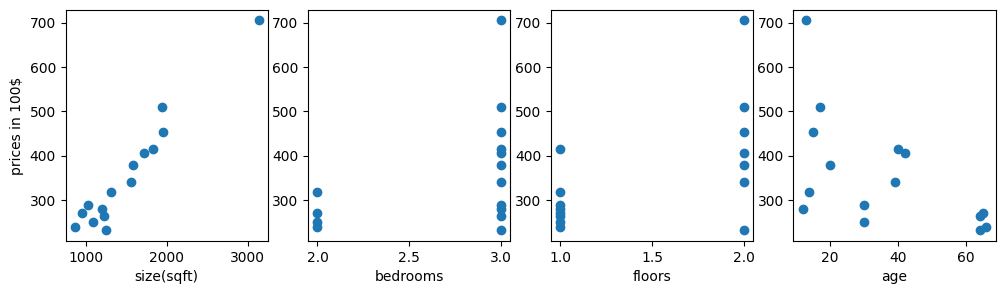

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 4, figsize=(12,3))
for i in range(len(X_features)):
    ax[i].scatter(X_train[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("prices in 100$")

compute w,b and costfunction 

In [5]:
alpha = 6.0e-7
w_r = np.zeros(X_train.shape[1])
b_r = 0.

for i in range(100000):
    if(i%1000 == 0):
        print(f"Cost of {i} iteration is {compute_cost(X_train,y_train,w_r,b_r)}")
    dw,db = gradient(X_train,y_train,w_r,b_r)
    w_r = w_r-alpha*dw
    b_r = b_r-alpha*db


Cost of 0 iteration is 71336.76233333333
Cost of 1000 iteration is 499.8514820551835
Cost of 2000 iteration is 498.8193538517896
Cost of 3000 iteration is 498.4095628346369
Cost of 4000 iteration is 498.2430239190223
Cost of 5000 iteration is 498.17156598281423
Cost of 6000 iteration is 498.137274107801
Cost of 7000 iteration is 498.11751137392275
Cost of 8000 iteration is 498.1034297986118
Cost of 9000 iteration is 498.09157101342345
Cost of 10000 iteration is 498.08058326185596
Cost of 11000 iteration is 498.06993818845035
Cost of 12000 iteration is 498.05942927645964
Cost of 13000 iteration is 498.04897580465
Cost of 14000 iteration is 498.038546220863
Cost of 15000 iteration is 498.02812819141235
Cost of 16000 iteration is 498.0177168944449
Cost of 17000 iteration is 498.00731044421985
Cost of 18000 iteration is 497.99690810261984
Cost of 19000 iteration is 497.9865095800961
Cost of 20000 iteration is 497.97611476242747
Cost of 21000 iteration is 497.9657236039259
Cost of 22000 ite

Lets define function of z-score

In [6]:
def zscore(x):
    mu = np.mean(x,axis=0) #mean
    sigma = np.std(x,axis=0) #standard deviation
    x_norm = (x-mu)/sigma
    return x_norm,mu,sigma

Compute the data with normalization

Text(0, 0.5, 'Price')

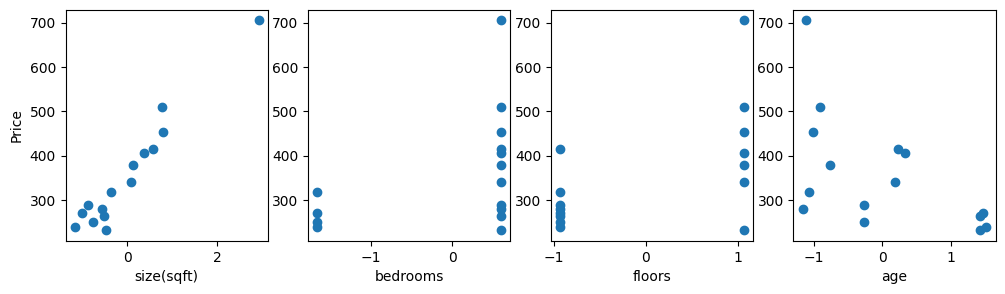

In [7]:
X_norm,mu,sigma = zscore(X_train)

fig, ax = plt.subplots(1,4,figsize=(12,3))
for i in range(len(X_features)):
    ax[i].scatter(X_norm[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price")

Notice that before and after normalization graph looks similar but the axis varies

In [8]:
#After normalization we take learning as 0.1 and increase x3 to check the cost function variation

alpha = 0.1
w_norm = np.zeros(X_train.shape[1])
b_norm = 0.

for i in range(10000):
    if(i%1000 == 0):
        print(f"Cost of {i} iteration is {compute_cost(X_norm,y_train,w_norm,b_norm )}")
    dw,db = gradient(X_norm,y_train,w_norm,b_norm )
    w_norm = w_norm-alpha*dw
    b_norm  = b_norm -alpha*db

Cost of 0 iteration is 71336.76233333333
Cost of 1000 iteration is 373.9828966186099
Cost of 2000 iteration is 373.9828966186099
Cost of 3000 iteration is 373.9828966186099
Cost of 4000 iteration is 373.9828966186099
Cost of 5000 iteration is 373.9828966186099
Cost of 6000 iteration is 373.9828966186099
Cost of 7000 iteration is 373.9828966186099
Cost of 8000 iteration is 373.9828966186099
Cost of 9000 iteration is 373.9828966186099


Before Scaling, Cost function value is 497..
After Scaling, cost function value is 373...

Same data but after normalization model works better as all the datapoints fit into similar range

Let's understand the terminology below and calculate scaled and unscaled prediction quality:


**MAE (Mean Absolute Error)** — average size of the errors, ignoring direction (over/under prediction treated the same).

$$MAE = \frac{1}{m} \sum_{i=1}^{m} \left| y^{(i)} - \hat{y}^{(i)} \right|$$

**RMSE (Root Mean Squared Error)** — average error size, but squares errors first (so big misses are punished harder), then square-roots back to original units.

$$RMSE = \sqrt{\frac{1}{m} \sum_{i=1}^{m} \left( y^{(i)} - \hat{y}^{(i)} \right)^2}$$

**R² (R-squared / coefficient of determination)** — how much better the model is than just predicting the average every time. 1.0 = perfect, 0 = no better than guessing the mean.

$$R^2 = 1 - \frac{\sum_{i=1}^{m} \left( y^{(i)} - \hat{y}^{(i)} \right)^2}{\sum_{i=1}^{m} \left( y^{(i)} - \bar{y} \right)^2}$$

where $\hat{y}^{(i)}$ is the predicted value, $y^{(i)}$ is the actual value, and $\bar{y}$ is the mean of actual values.

In [9]:
def r_squared(y, y_pred):
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - ss_res/ss_tot

def mae(y, y_pred):
    return np.mean(np.abs(y - y_pred))

def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred)**2))

In [10]:
pred_unscaled = X_train @ w_r + b_r
pred_scaled = X_norm @ w_norm + b_norm

**X_norm @ w_norm + b_norm — worked example**

*(Illustrative numbers below, not the actual trained values from this notebook — just to show how the matrix multiply produces predictions.)*

Say we have 3 houses, 2 features each (size_z, rooms_z — already z-scored).

**X_norm** (3×2):
```
[ 0.5, -1.0]
[-1.0,  0.0]
[ 1.2,  1.5]
```

**w_norm** (2×1, learned weights — one per feature):
```
[50000]
[10000]
```

**b_norm** (scalar): `300000`

---

**Step 1 — X_norm @ w_norm**

Each row does a dot product with w_norm:

- Row 1: (0.5 × 50000) + (-1.0 × 10000) = 25000 − 10000 = **15000**
- Row 2: (-1.0 × 50000) + (0.0 × 10000) = −50000 + 0 = **−50000**
- Row 3: (1.2 × 50000) + (1.5 × 10000) = 60000 + 15000 = **75000**

Result (3×1):
```
[ 15000]
[-50000]
[ 75000]
```

---

**Step 2 — add b_norm (300000) to every row**

```
[315000]
[250000]
[375000]
```

This final 3×1 vector **is** `pred_scaled` — one predicted price per house, in real dollars.

---

Shape rule: `(m rows × n features) @ (n features × 1) = (m rows × 1)` — one prediction per row, no matter how many features you have.

In [11]:
print("Unscaled model:")
print("  R2:", r_squared(y_train, pred_unscaled))
print("  MAE:", mae(y_train, pred_unscaled))
print("  RMSE:", rmse(y_train, pred_unscaled))

print("Scaled model:")
print("  R2:", r_squared(y_train, pred_scaled))
print("  MAE:", mae(y_train, pred_scaled))
print("  RMSE:", rmse(y_train, pred_scaled))

Unscaled model:
  R2: 0.9347512910192943
  MAE: 24.553555586165814
  RMSE: 31.532718005425252
Scaled model:
  R2: 0.9509170286494644
  MAE: 22.674961445299356
  RMSE: 27.348963293646424
